In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
import shap
from sklearn.inspection import PartialDependenceDisplay

In [2]:
ft_features = pd.read_csv('ft_features_combined_iso_11_05.csv')
ft_properties = pd.read_csv('ft_properties_combined_iso_03_05.csv')
# for col in ft_features.columns:
#     print(col)
# for col in ft_properties.columns:
#     print(col)


In [10]:
feature_column_rename = {'TOS [h]': 'TOS (h)', 'p(PHG) [bar]': 'p(PHG) (bar)', 'GHSV_PV [h-1]':'GHSV_PV (h-1)'}
ft_features.rename(feature_column_rename, axis=1, inplace=True)
# ft_features.drop(['TOS (h)'], axis=1, inplace=True)

ft_features['Catalyst_form_pellet'] = ft_features['Catalyst_form_pellet'].astype(int)
ft_features['Catalyst_form_powder'] = ft_features['Catalyst_form_powder'].astype(int)
# ft_features = ft_features[['%Mn', 'Ratio_H2/CO_in', 'Catalyst_form_pellet', 'Catalyst_form_powder']]
print(list(ft_features.columns))
print(list(ft_properties.columns))


['TOS (h)', 'T-Rx', '%Co', '%Mn', 'p(PHG) (bar)', 'GHSV_PV (h-1)', 'Ratio_H2/CO_in', 'partial_pressure_H2', 'partial_pressure_CO', 'Catalyst_form_pellet', 'Catalyst_form_powder']
['CO conversion', 'S_Methane', 'S_Methanol', 'S_C2-C4_paraffins', 'S_C5-C10_paraffins', 'S_C10+_paraffins', 'S_C2-C4_olefins', 'S_C5-C10_olefins', 'S_C10+_olefins', 'S_C2-C4_OH', 'S_C5-C10_OH', 'S_C10+_OH', 'S_C2-C4', 'S_C5+', 'S_C10+']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_features = [
    "TOS (h)", "T-Rx", "%Co", "%Mn",
    "p(PHG) (bar)", "GHSV_PV (h-1)",
    "partial_pressure_H2", "partial_pressure_CO"
]

cat_features = [
    "PSD"   # assuming this is categorical (powder/pellet or encoded)
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", "passthrough", cat_features)
    ]
)

### XGB

In [4]:
model_name = 'XGB'
columns = []
with open(f'models/{model_name}_best_parameters_combined_data_iso.pkl','rb') as f:
    best_parameters = pickle.load(f)
print(best_parameters)
for col, parameters in best_parameters.items():
    print(col,'\n')

    y = ft_properties[col]
    X = ft_features

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print('---------------Running with best parameters--------------')
    if model_name == 'linear':
        pass
    else:
        model = XGBRegressor(**parameters)
        model.fit(X_train, y_train)

    #save models
    #     joblib.dump(model, open(f'models/model_random_forest_best_parameter_{col}.sav','wb'))

    with open(f'models/model_{model_name}_best_parameter_{col}.pkl','wb') as f:
        pickle.dump(model,f)
#     with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#         model = pickle.load(f)

    y_pred = model.predict(X_train)
    # test the models on already seen data
    r2 = r2_score(y_train, y_pred)
    print('r2 for train: ', r2)
    mae = mean_absolute_error(y_train, y_pred)
    print('MAE for train: ', mae)
    mse = mean_squared_error(y_train, y_pred)
    print('RMSE for train: ', mse**(1/2), '\n')

    y_pred = model.predict(X_test)
    # test the models for prediction on unseen data
    r2 = r2_score(y_test, y_pred)
    print('r2 for test: ', r2)
    mae = mean_absolute_error(y_test, y_pred)
    print('MAE for test: ', mae)
    mse = mean_squared_error(y_test, y_pred)
    print('RMSE for test: ', mse**(1/2), '\n')

{'CO conversion': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_Methane': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 250}, 'S_Methanol': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C2-C4_paraffins': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C5-C10_paraffins': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 250}, 'S_C10+_paraffins': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C2-C4_olefins': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 250}, 'S_C5-C10_olefins': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C10+_olefins': {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 250}, 'S_C2-C4_OH': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C5-C10_OH': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}, 'S_C10+_OH': {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 250}, 'S_C2-C4': {'learning_rate': 0.1, 'max_depth': 6, 'n_est

<Axes: xlabel='%Mn', ylabel='S_C5-C10_OH'>

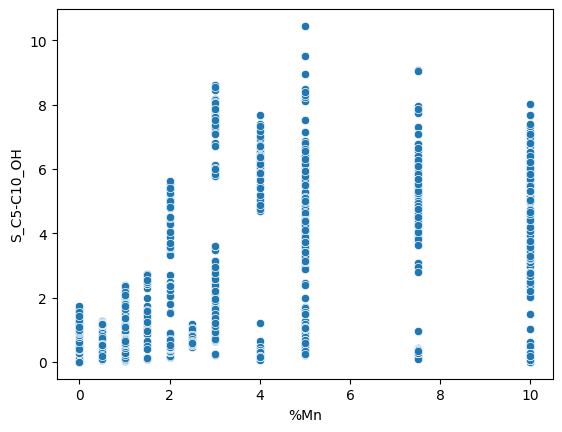

In [7]:
sns.scatterplot(x='%Mn', y='S_C5-C10_OH', data=pd.concat([ft_features, ft_properties], axis=1))
# sns.scatterplot(x='CO conversion', y='S_C10+_paraffins', data=pd.concat([ft_features, ft_properties], axis=1))

CO conversion 

S_Methane 

S_Methanol 

S_C2-C4_paraffins 

S_C5-C10_paraffins 

S_C2-C4_olefins 

S_C5-C10_olefins 

S_C2-C4_OH 

S_C5-C10_OH 



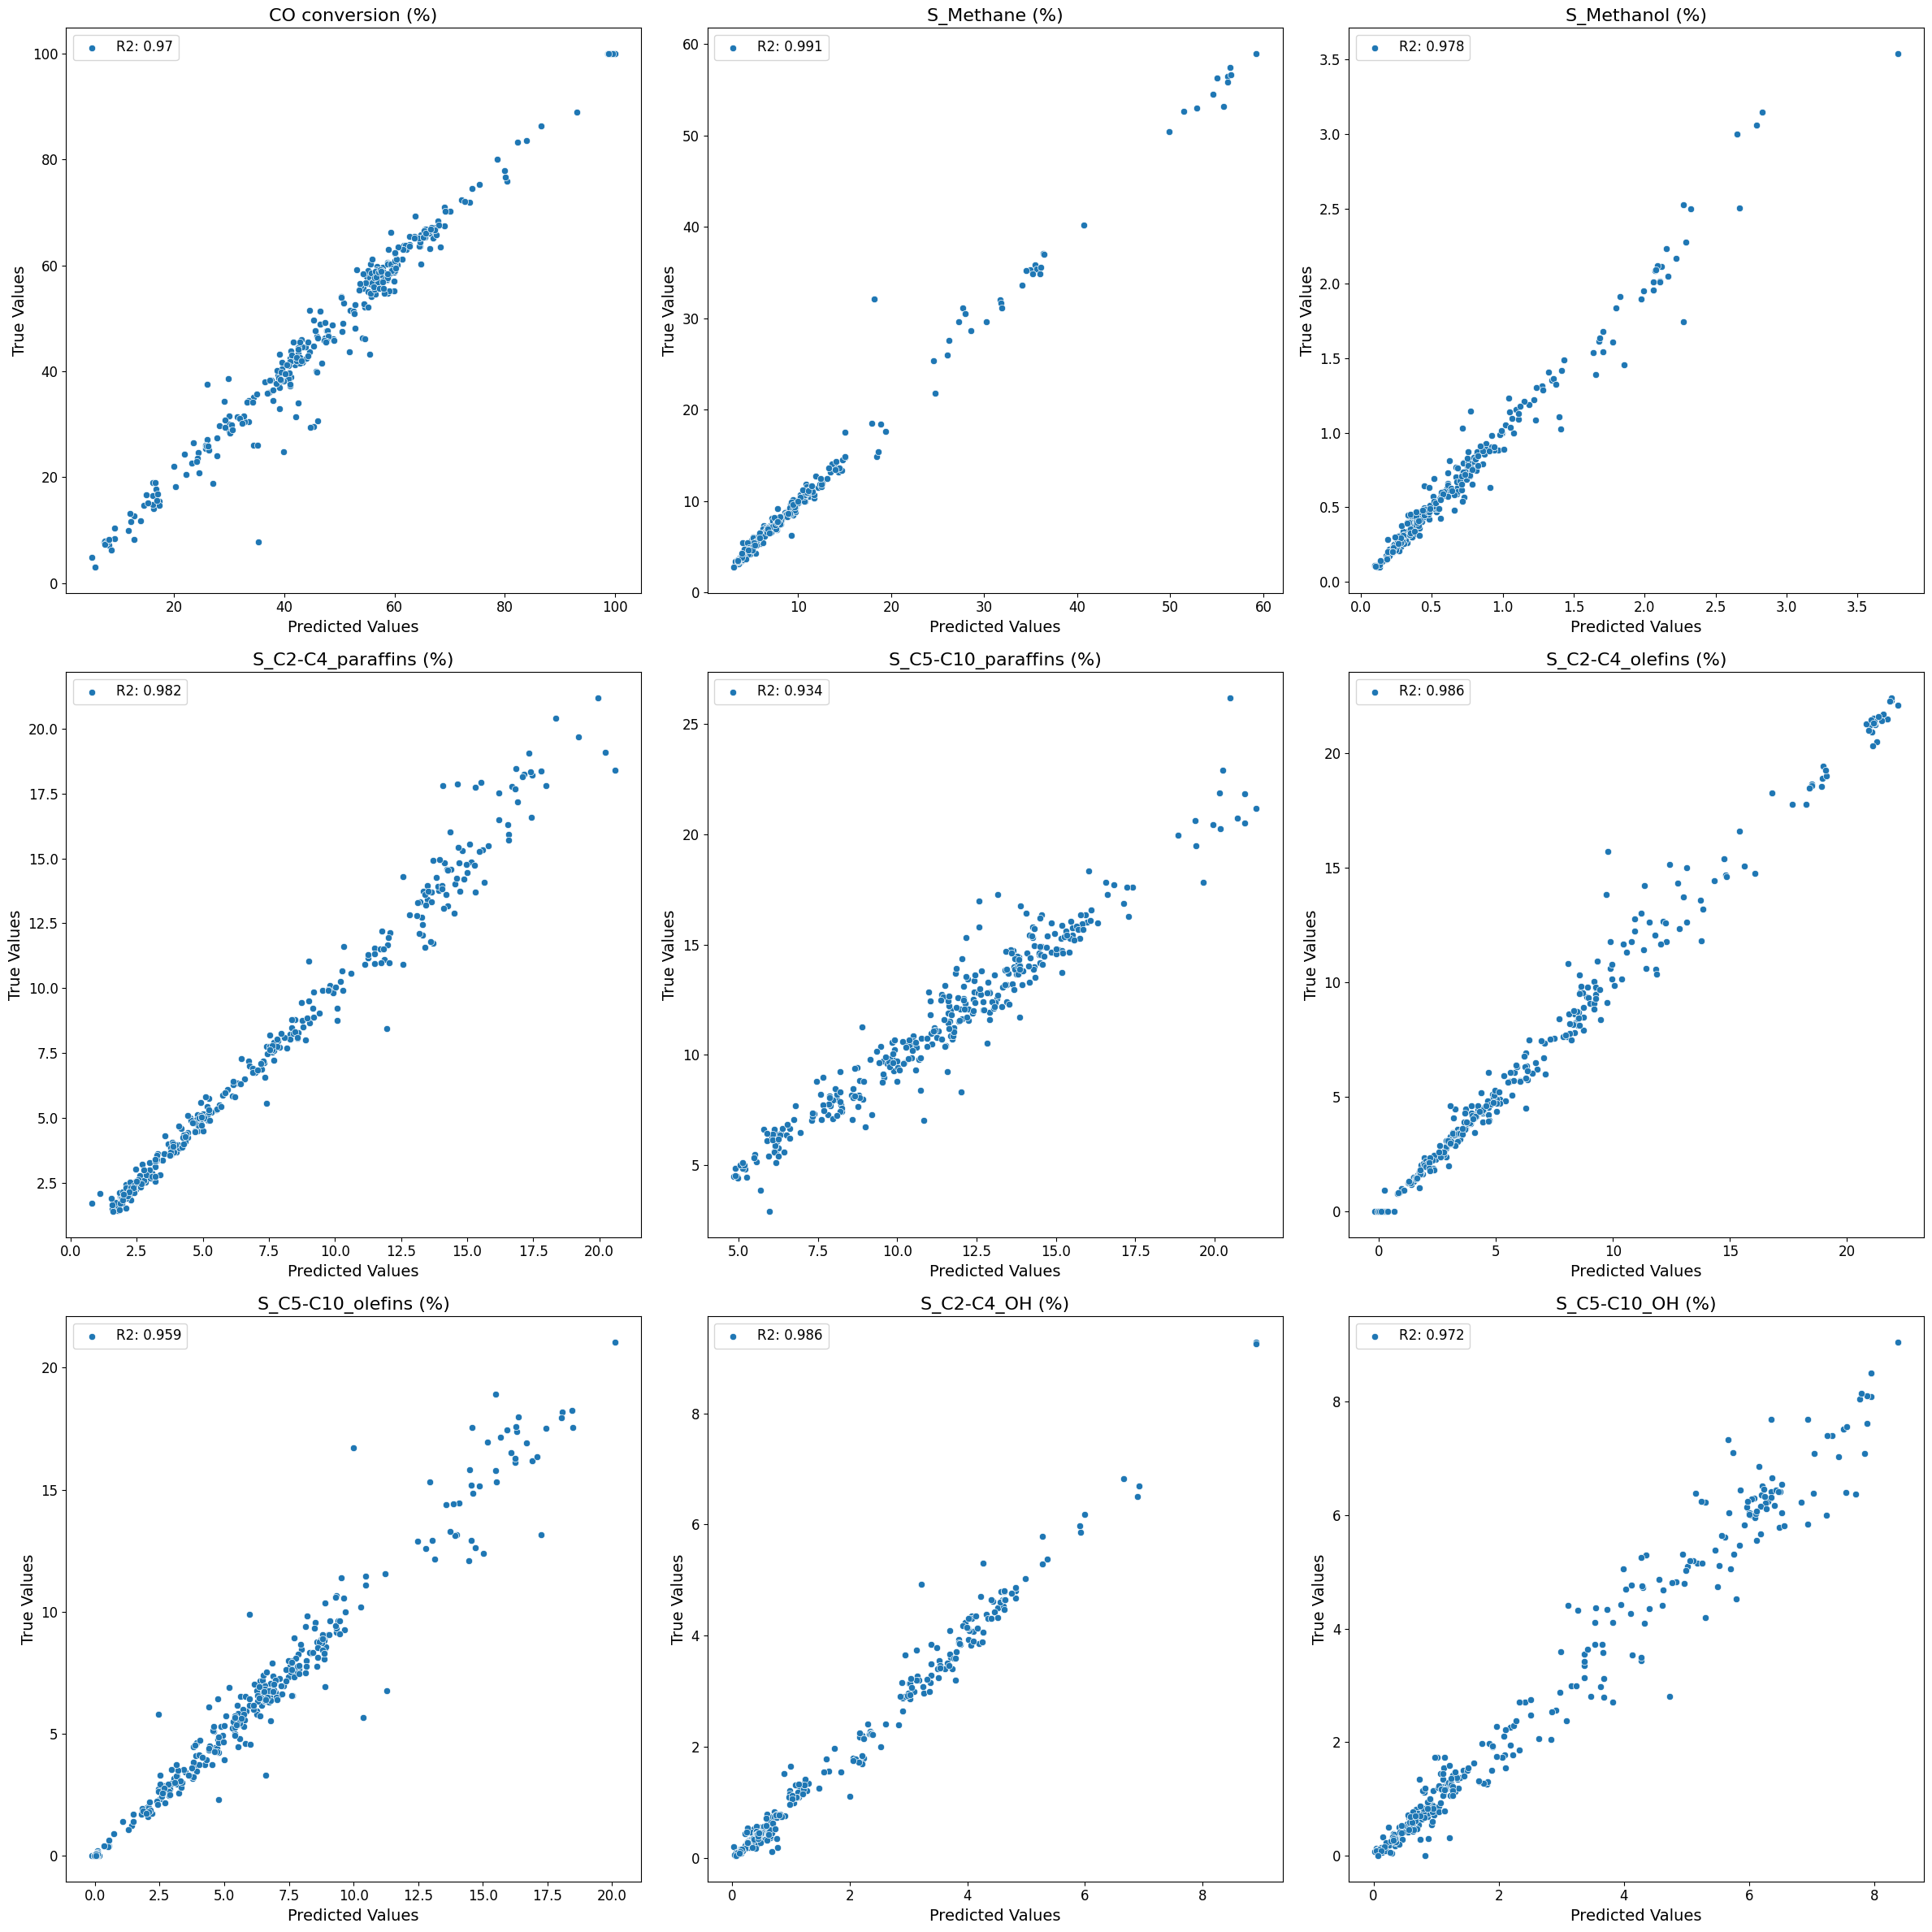

In [12]:
plt.rcParams.update({
    'font.size': 14,          # base font
    'axes.titlesize': 16,     # subplot titles
    'axes.labelsize': 14,     # x/y labels
    'xtick.labelsize': 12,    # x tick labels
    'ytick.labelsize': 12,    # y tick labels
    'legend.fontsize': 12
})

model_name = 'XGB'
X = ft_features
include_targets = ['CO conversion', 'S_Methane', 'S_Methanol', 'S_C2-C4_paraffins', 'S_C5-C10_paraffins', 
                   'S_C2-C4_olefins', 'S_C5-C10_olefins', 'S_C2-C4_OH', 'S_C5-C10_OH']
fig, ax = plt.subplots(3,3,figsize=(24,24))
ax = ax.flatten()
for i, col in enumerate(include_targets):
    print(col,'\n')
    with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
        model = pickle.load(f)
    y = ft_properties[col]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test)
    residual = y_test-y_pred
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2 = 1 - ss_res / ss_tot
    sns.scatterplot(x=y_pred, y=y_test, alpha=1, ax=ax[i], label=f'R2: {np.round(r2,3)}')
    ax[i].set_xlabel("Predicted Values")
    ax[i].set_ylabel("True Values")
    ax[i].set_title(f"{col} (%)")
    ax[i].legend()
plt.tight_layout()
plt.savefig(f'Parity plots XGB for report - combined data.png')
plt.show()
fig.clear()

S_Methane 



 99%|===================| 1352/1367 [00:45<00:00]        

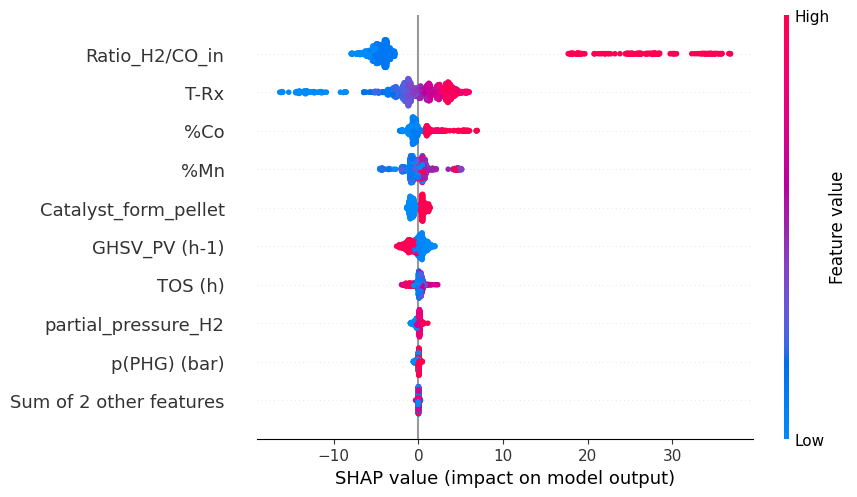

In [33]:
model_name = 'XGB'
column_name_list = ['TOS', 'T', '%Co', '%Mn', 'Total Pressure', 'GHSV', 'Ratio H2/CO ', 
                    'partial_pressure_H2', 'partial_pressure_CO', 'Catalyst_form_pellet', 
                    'Catalyst_form_powder']
for col in ft_properties.columns[1:2]:
    print(col,'\n')
    X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
    with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
        model = pickle.load(f)
    explainer = shap.Explainer(model, X_train_df)
    
    shap_values = explainer(X_train_df)
    fig = shap.plots.beeswarm(shap_values, show=False)
    plt.savefig(f'SHAP_beeswarm_{model_name}_{col}.jpg', bbox_inches='tight')
    
#     fig = shap.summary_plot(shap_values, X_train_df)
#     plt.savefig(f'SHAP_bar_{model_name}_{col}.jpg', bbox_inches='tight')
#     shap.plots.bar(shap_values)
#     shap.dependence_plot("T-Rx", shap_values.values, X)
#     shap.summary_plot(shap_values, X)

 99%|===================| 1690/1709 [00:55<00:00]        

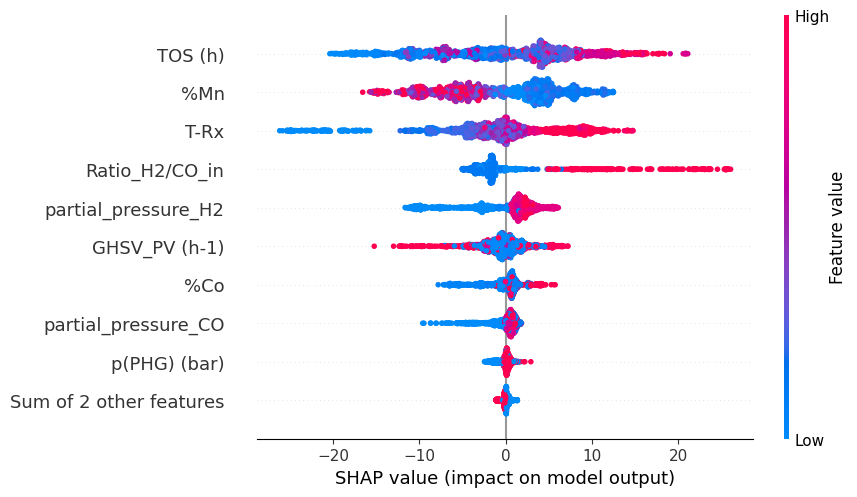

In [10]:
model_name = 'XGB'
col = 'CO conversion'
X = ft_features
y = ft_properties[col]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
X_test_df = pd.DataFrame(X_test,columns=ft_features.columns)
with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
    model = pickle.load(f)
explainer = shap.Explainer(model, X)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values)

S_C5-C10_olefins 



 94%|=================== | 1283/1367 [00:14<00:00]       

<bound method Series.info of TOS (h)                 0.560277
T-Rx                    0.531824
%Co                     0.617841
%Mn                     1.346955
p(PHG) (bar)            2.601265
GHSV_PV (h-1)           0.306855
Ratio_H2/CO_in          1.039101
partial_pressure_H2     0.292380
partial_pressure_CO     0.175910
Catalyst_form_pellet    1.054776
Catalyst_form_powder    0.000000
dtype: float64>
p(PHG) (bar)


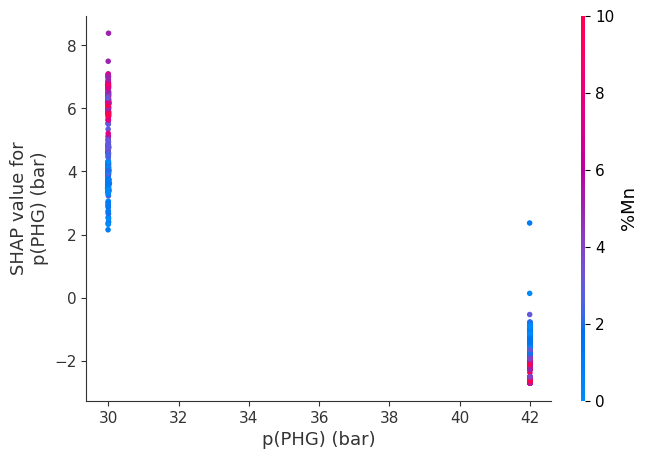

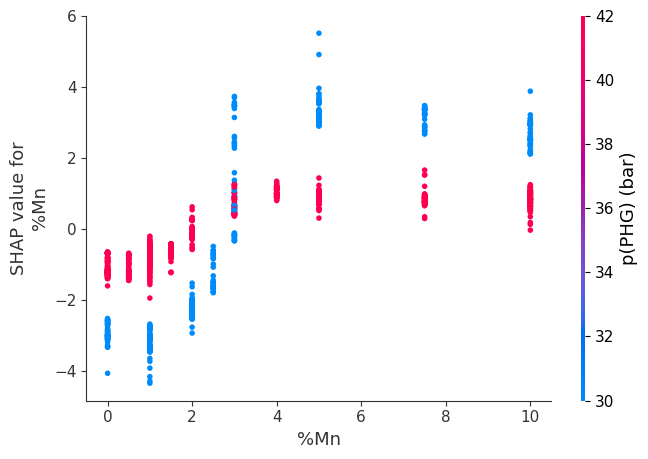

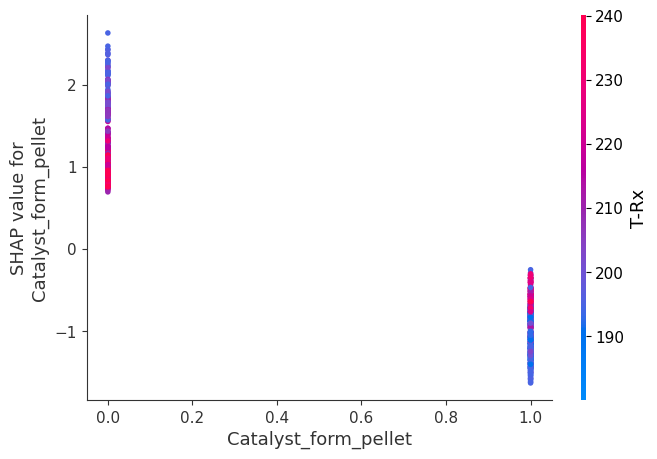

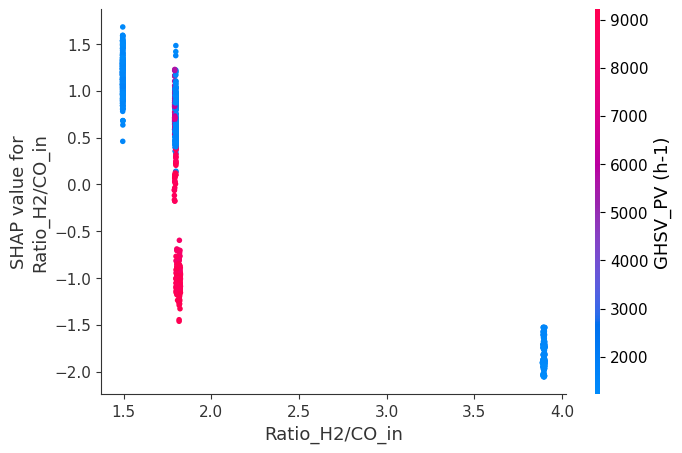

In [18]:
model_name = 'XGB'
col = 'S_C5-C10_olefins'
y = ft_properties[col]
X = ft_features
print(col,'\n')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
    model = pickle.load(f)
explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_train_df)

importance = np.abs(shap_values.values).mean(axis=0)

importance_series = pd.Series(importance, index=X.columns)
print(importance_series.info)

top_feature = importance_series.idxmax()

print(top_feature)
top_features = importance_series.sort_values(ascending=False).head(4).index.tolist()

for feat in top_features:
    shap.dependence_plot(feat, shap_values.values, X_train_df, interaction_index='auto')

S_C5-C10_paraffins 



 99%|===================| 1348/1367 [00:17<00:00]        

<bound method Series.info of TOS (h)                 1.073326
T-Rx                    0.433699
%Co                     0.599258
%Mn                     1.085787
p(PHG) (bar)            0.081147
GHSV_PV (h-1)           0.911563
Ratio_H2/CO_in          1.413316
partial_pressure_H2     0.182468
partial_pressure_CO     0.214651
Catalyst_form_pellet    0.220207
Catalyst_form_powder    0.000000
dtype: float64>
Ratio_H2/CO_in


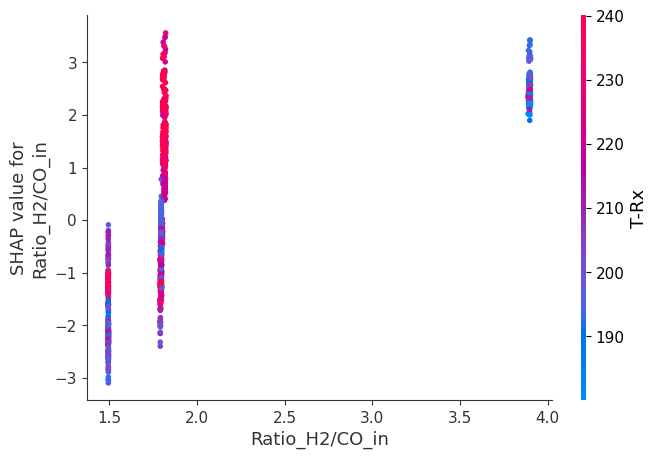

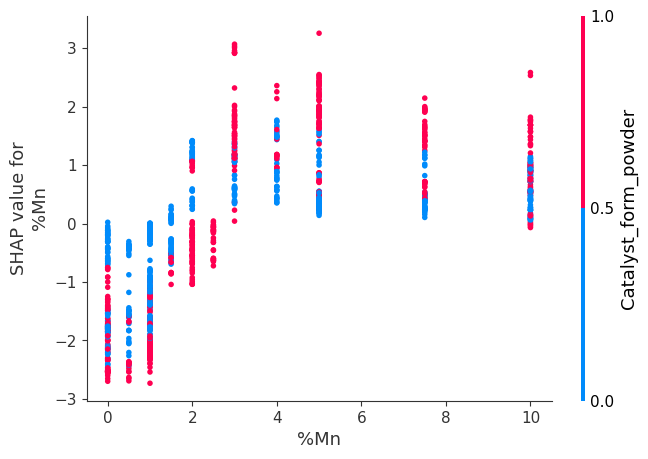

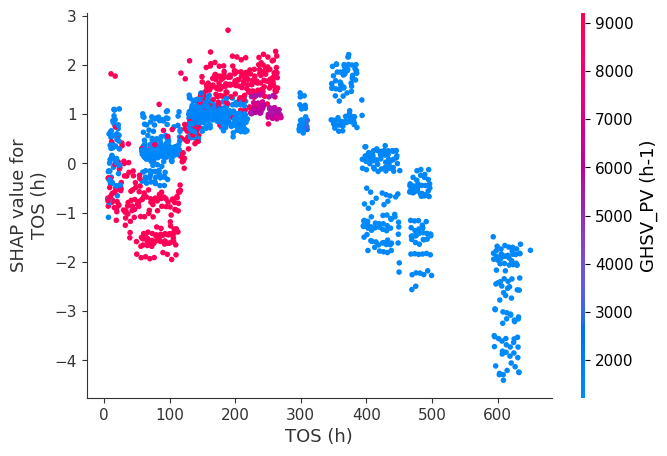

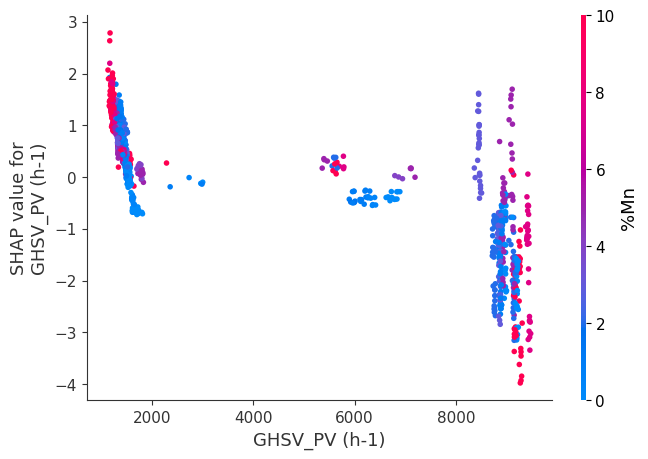

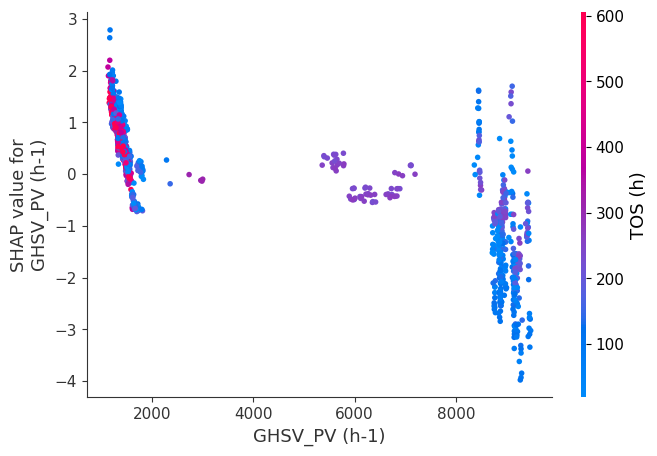

In [17]:
model_name = 'XGB'
col = 'S_C5-C10_paraffins'
y = ft_properties[col]
X = ft_features
print(col,'\n')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
    model = pickle.load(f)
explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_train_df)

importance = np.abs(shap_values.values).mean(axis=0)

importance_series = pd.Series(importance, index=X.columns)
print(importance_series.info)

top_feature = importance_series.idxmax()

print(top_feature)
top_features = importance_series.sort_values(ascending=False).head(4).index.tolist()

for feat in top_features:
    shap.dependence_plot(feat, shap_values.values, X_train_df, interaction_index='auto')
shap.dependence_plot('GHSV_PV (h-1)', shap_values.values, X_train_df, interaction_index='TOS (h)')

In [ ]:
for i, col in enumerate(ft_features.columns):
    print(f'Feature {i}: {col}')

#### PDP

S_C2-C4_olefins 



C:\Users\akash\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:972: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


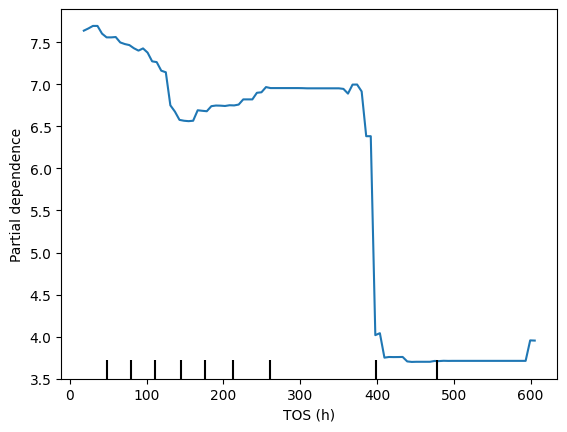

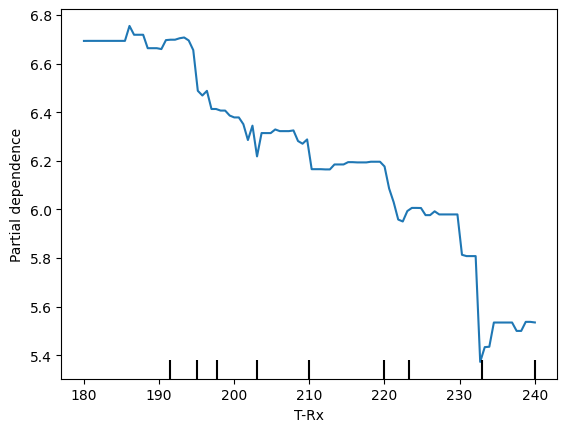

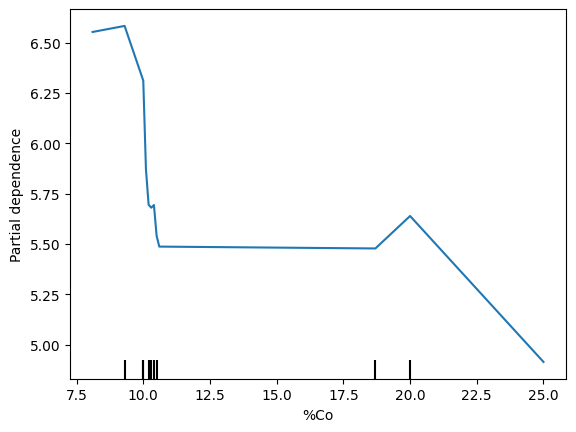

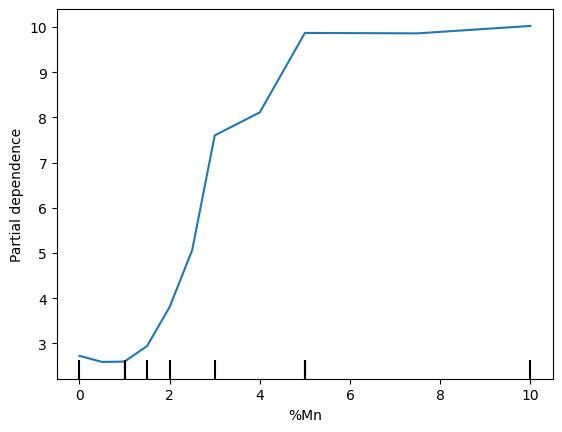

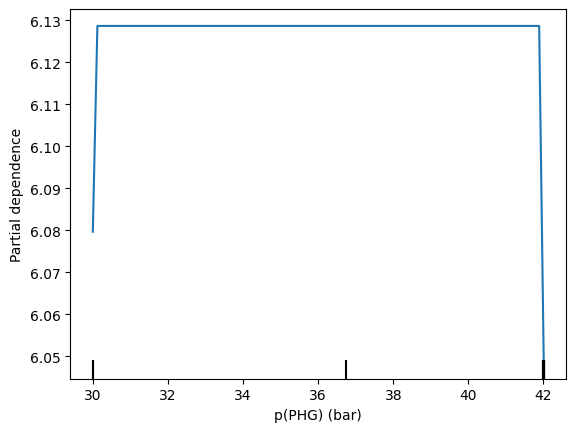

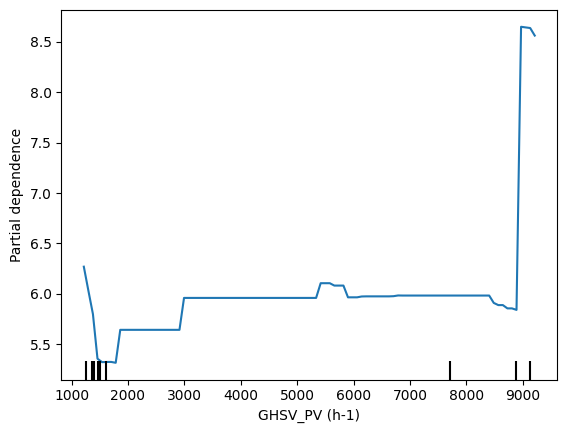

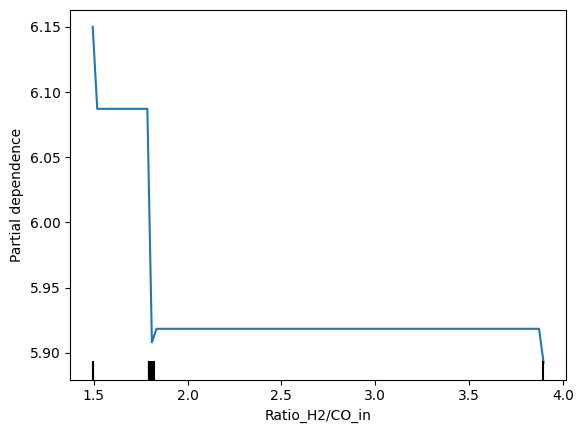

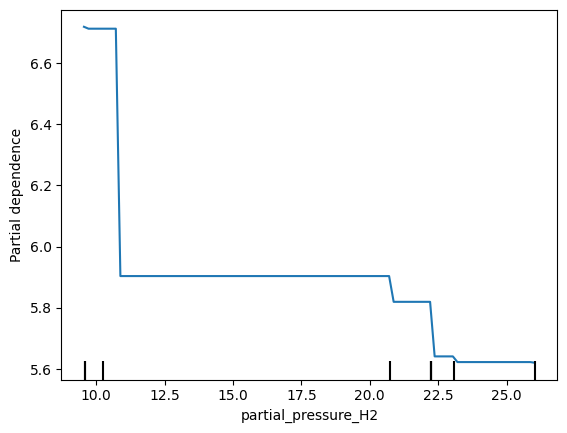

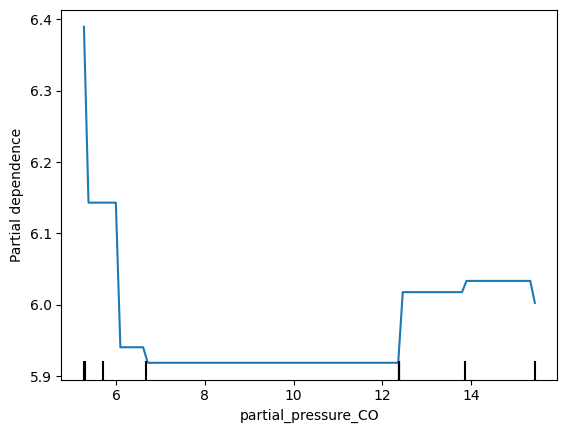

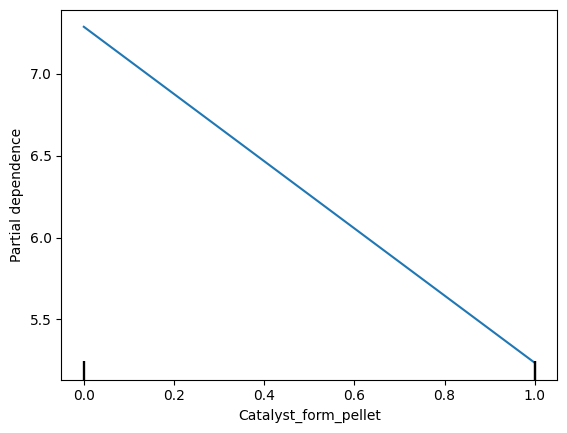

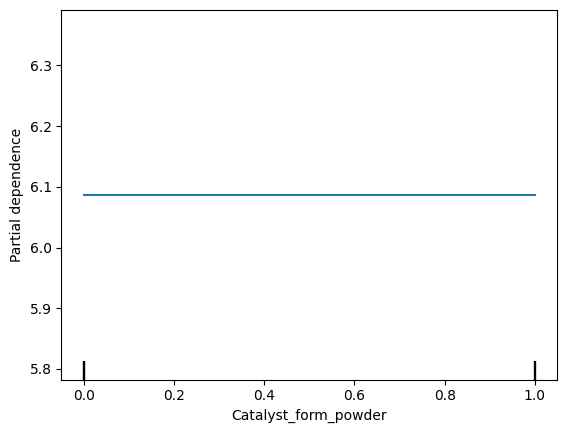

In [8]:
model_name='XGB'
col = 'S_C2-C4_olefins'
X = ft_features
y = ft_properties[col]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
# sns.scatterplot(x=col, y=col, data=ft_properties)
# for i, col in enumerate(ft_properties.columns[:-1]):
print(col,'\n')
with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
    model = pickle.load(f)
for j, feat in enumerate(ft_features.columns):
    features = [feat]
    PartialDependenceDisplay.from_estimator(model, X_train_df, features)

### Permutation importance

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
model_name = 'XGB'
for col in ft_properties.columns:
    print(col,'\n')

    y = ft_properties[col]
    X = ft_features

    with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
        model = pickle.load(f)

    r = permutation_importance(model, X_train, y_train, n_repeats=30,random_state=0)
    for i in r.importances_mean.argsort()[::-1]:
        if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
            print(f"{list(ft_features.columns)[i]:<8} "
                  f"{r.importances_mean[i]:.3f}"
                  f" +/- {r.importances_std[i]:.3f}")

### Gradient boost

In [7]:
model_name = 'gradient_boost'
columns = []
with open(f'models/{model_name}_best_parameters_combined_data_iso.pkl','rb') as f:
    best_parameters = pickle.load(f)
print(best_parameters)
for col, parameters in best_parameters.items():
    print(col,'\n')

    y = ft_properties[col]
    X = ft_features

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print('---------------Running with best parameters--------------')
    if model_name == 'linear':
        pass
    else:
        model = GradientBoostingRegressor(**parameters)
        model.fit(X_train, y_train)

    #save models
    #     joblib.dump(model, open(f'models/model_random_forest_best_parameter_{col}.sav','wb'))

    with open(f'models/model_{model_name}_best_parameter_{col}.pkl','wb') as f:
        pickle.dump(model,f)
#     with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#         model = pickle.load(f)

    y_pred = model.predict(X_train)
    # test the models on already seen data
    r2 = r2_score(y_train, y_pred)
    print('r2 for train: ', r2)
    mae = mean_absolute_error(y_train, y_pred)
    print('MAE for train: ', mae)
    mse = mean_squared_error(y_train, y_pred)
    print('RMSE for train: ', mse**(1/2), '\n')

    y_pred = model.predict(X_test)
    # test the models for prediction on unseen data
    r2 = r2_score(y_test, y_pred)
    print('r2 for test: ', r2)
    mae = mean_absolute_error(y_test, y_pred)
    print('MAE for test: ', mae)
    mse = mean_squared_error(y_test, y_pred)
    print('RMSE for test: ', mse**(1/2), '\n')

{'CO conversion': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.6}, 'S_Methane': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.9}, 'S_Methanol': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}, 'S_C2-C4_paraffins': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}, 'S_C5-C10_paraffins': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}, 'S_C10+_paraffins': {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.9}, 'S_C2-C4_olefins': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.6}, 'S_C5-C10_olefins': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}, 'S_C10+_olefins': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}, 'S_C2-C4_OH': {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.6}, 'S_C5-C10_OH': {'learnin

In [6]:
# model_name = 'gradient_boost'
# for col in ft_properties.columns:
#     print(col,'\n')
#     with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#         model = pickle.load(f)
#     y = ft_properties[col]
#     from sklearn.model_selection import train_test_split
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
#     from sklearn.preprocessing import StandardScaler
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
#     y_pred = model.predict(X_test)
#     residual = y_test-y_pred
#     ss_res = np.sum(residual**2)
#     ss_tot = np.sum((y_test - np.mean(y_test))**2)
#     r2 = 1 - ss_res / ss_tot
#     fig, ax = plt.subplots(1,5,figsize=(25,5))
#     sns.scatterplot(x=y_pred, y=residual, alpha=0.7, ax=ax[0])
#     sns.histplot(residual, bins=10, ax=ax[1])
#     sns.kdeplot(residual, fill=True, ax=ax[2])
#     sns.boxplot(x=residual, ax=ax[3])
#     sns.scatterplot(x=y_pred, y=y_test, alpha=0.7, ax=ax[4], label=f'R2: {np.round(r2,3)}')
#     ax[0].axhline(0, color='red', linestyle='--', linewidth=1)
#     ax[0].set_title(f"Residuals vs Predictions ({col})")
#     ax[0].set_xlabel("Predicted Values")
#     ax[0].set_ylabel("Residuals")
#     ax[1].set_title(f"Histogram of Residuals ({col})")
#     ax[2].set_title(f"Error Distribution ({col})")
#     ax[3].set_title(f"Boxplot of Residuals ({col})")
#     ax[1].set_xlabel("Residuals")
#     ax[2].set_xlabel("Residuals")
#     ax[3].set_xlabel("Residuals")
#     ax[4].set_xlabel("Predicted Values")
#     ax[4].set_ylabel("True Values")
#     ax[4].set_title(f"True values vs Predicted values ({col})")
#     plt.legend()
# #     plt.savefig(f'Performance of Random forest on test set for {col}.png')
#     plt.show()
#     fig.clear()

In [13]:
model_name = 'random_forest'
columns = []
with open(f'models/{model_name}_best_parameters_combined_data_iso.pkl','rb') as f:
    best_parameters = pickle.load(f)
print(best_parameters)
for col, parameters in best_parameters.items():
    print(col,'\n')

    y = ft_properties[col]
    X = ft_features

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print('---------------Running with best parameters--------------')
    if model_name == 'linear':
        pass
    else:
        model = RandomForestRegressor(**parameters)
        model.fit(X_train, y_train)

    #save models
    #     joblib.dump(model, open(f'models/model_random_forest_best_parameter_{col}.sav','wb'))

    with open(f'models/model_{model_name}_best_parameter_{col}.pkl','wb') as f:
        pickle.dump(model,f)
#     with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#         model = pickle.load(f)

    y_pred = model.predict(X_train)
    # test the models on already seen data
    r2 = r2_score(y_train, y_pred)
    print('r2 for train: ', r2)
    mae = mean_absolute_error(y_train, y_pred)
    print('MAE for train: ', mae)
    mse = mean_squared_error(y_train, y_pred)
    print('RMSE for train: ', mse**(1/2), '\n')

    y_pred = model.predict(X_test)
    # test the models for prediction on unseen data
    r2 = r2_score(y_test, y_pred)
    print('r2 for test: ', r2)
    mae = mean_absolute_error(y_test, y_pred)
    print('MAE for test: ', mae)
    mse = mean_squared_error(y_test, y_pred)
    print('RMSE for test: ', mse**(1/2), '\n')

{'CO conversion': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}, 'S_Methane': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}, 'S_Methanol': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 100}, 'S_C2-C4_paraffins': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}, 'S_C5-C10_paraffins': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}, 'S_C10+_paraffins': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 250}, 'S_C2-C4_olefins': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 250}, 'S_C5-C10_olefins': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}, 'S_C10+_olefins': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}, 'S_C2-C4_OH': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}, 'S_C5-C10_OH': {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}, 'S_C10+_OH': {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 100}, 'S_C2-C4': {'max_depth': 15, 'min_sam

CO conversion 



 99%|===================| 1351/1367 [00:17<00:00]        

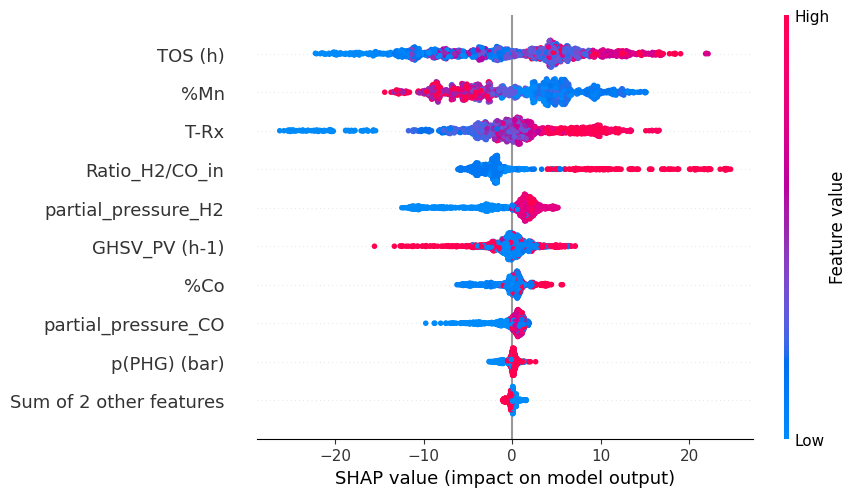

In [24]:
model_name = 'XGB'
col = 'CO conversion'
print(col,'\n')
X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
    model = pickle.load(f)
explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_train_df)
# shap.plots.beeswarm(shap_values)

fig = shap.plots.beeswarm(shap_values, show=False)
plt.savefig('SHAP_beeswarm_XGB_CO_conversion.jpg', bbox_inches='tight')

# model_name = 'gradient_boost'
# print(col,'\n')
# X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
# with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#     model = pickle.load(f)
# explainer = shap.Explainer(model, X_train_df)
# shap_values = explainer(X_train_df,check_additivity=False)
# shap.plots.beeswarm(shap_values)

# model_name = 'random_forest'
# print(col,'\n')
# X_train_df = pd.DataFrame(X_train,columns=ft_features.columns)
# with open(f'models/model_{model_name}_best_parameter_{col}.pkl', 'rb') as f:
#     model = pickle.load(f)
# explainer = shap.Explainer(model, X_train_df)
# shap_values = explainer(X_train_df,check_additivity=False)
# shap.plots.beeswarm(shap_values)
#     shap.plots.bar(shap_values)
#     shap.dependence_plot("T-Rx", shap_values.values, X)
#     shap.summary_plot(shap_values, X)

In [ ]:
ft_data = pd.concat([ft_features, ft_properties], axis=1)
print(ft_data.info)

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(ft_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Correlation Matrix", fontsize=18, weight='bold')
# plt.savefig('correlation heatmap.png')
plt.show()